In [1]:
from obspy import *
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np
import datetime

In [2]:
#%run vnda_picker_orig.py 2025-11-21T03:00:00 2025-11-21T03:15:00 #add something to the code to prevent double picking

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x105f7bfd0>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x14e989550>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.4.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-04-28T12%3A50%3A00.000000&endtime=2026-04-28T13%3A00%3A00.000000&network=%2A&station=I54H1&location=%2A&channel=%2A with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-28T12%3A49%3A58.100000&endtime=2026-04-28T13%3A00%3A11.050000&network=IM&station=I54H1&location=--&channel=BDF&level=response with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-28T12%3A49%3A52.800000&endtime=2026-04-28T13%3A00%3A01.050000&network=IM&station=I54H1&location=--&channel=BE1&level=response with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-28T12%3A49%3A55.000000&endtime=2026-04-28T13%3A00%3A14.850000&network=IM&station=I54H1&location=--&channel=BE2&level=response with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-28T12%3A49%3A42.550000&endtime=2026-04-28T13%3A00%3A09.100000&network=IM&station=I54H1&location=--&channel=BE3&level=response with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-28T12%3A49%3A48.700000&endtime=2026-04-28T13%3A00%3A01.950000&network=IM&station=I54H1&location=--&channel=BE4&level=response with HTTP code: 200


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (10) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


No earthquakes for this time period.


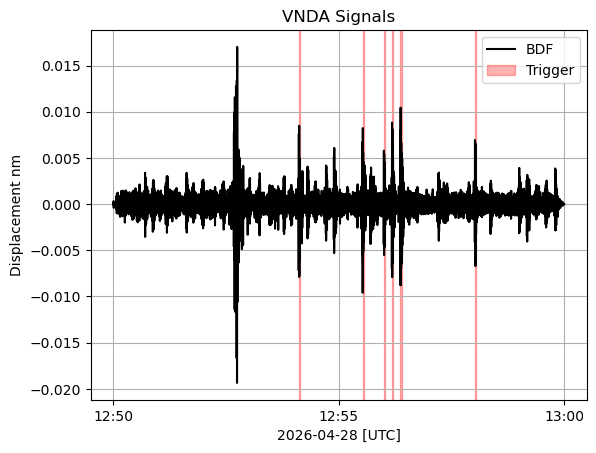

In [5]:
#Trying out the palmer picker

%run palmer_picker.py 2026-04-28T12:50:00 2026-04-28T13:00:00

In [3]:
#This is a visual check to see if the picker is selecting what want it to

#%run vnda_picker_orig.py 2025-11-21T01:59:00 2025-11-21T05:00:00
#%run vnda_picker_orig.py 2025-11-21T03:59:00 2025-11-21T07:00:00
#%run vnda_picker_orig.py 2025-11-21T05:59:00 2025-11-21T09:00:00
#%run vnda_picker_orig.py 2025-11-21T08:59:00 2025-11-21T11:00:00
#%run vnda_picker_orig.py 2025-11-21T10:59:00 2025-11-21T13:00:00
#%run vnda_picker_orig.py 2025-11-21T12:59:00 2025-11-21T15:00:00
#%run vnda_picker_orig.py 2025-11-21T14:59:00 2025-11-21T17:00:00
#%run vnda_picker_orig.py 2025-11-21T16:59:00 2025-11-21T19:00:00
#%run vnda_picker_orig.py 2025-11-21T18:59:00 2025-11-21T21:00:00
#%run vnda_picker_orig.py 2025-11-21T20:59:00 2025-11-21T23:59:59
#%run vnda_picker_orig.py 2025-11-22T00:00:00 2025-11-22T01:00:00
#%run vnda_picker_orig.py 2025-11-23T04:00:00 2025-11-23T05:00:00

In [4]:
def stat_plotter(df, df1):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()

    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'unfiltered') #local time
    ax.set_xlabel('Hours in Local Time (UTC+13)')
    ax.set_ylabel('Number of Triggers')
    
    ax.scatter(df1['hour_local'].unique(), df1.groupby(df1['local'].dt.hour).size(), color = 'red', label = 'Filtered for double count') #local time
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    
    #plt.show()
    #this was a check to make sure they look the same and not clipping anything. Looks good. 
    
    #fig, ax = plt.subplots()
    #ax.scatter(df['hour_UTC'].unique(), hour_utc) #UTC time
    #ax.set_xlabel('Hours in UTc Time')
    #ax.set_ylabel('Number of Triggers')
    #ax.set_title('Triggers Grouped by Time of Day (UTC)')
    #plt.show()
    
    
    #pick_5 = daily_utc/(24*60) #event time put y-axis in pick per 5 ish min, or pick per minute
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'unfiltered') #pick per hour
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), df1.groupby(df1['onset'].dt.day).size()/24, color = 'red', label = 'Filtered for double count')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per hour')
    ax.legend()
    
    fig.tight_layout(pad=3.0) 

    fig.add_gridspec(4, 4, wspace=0, hspace=0)
   
    #interevent time plot
   
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'unfiltered') 
    ax.hist(df1['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', color = 'red', label = 'filtered')
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()
    return None
    

In [5]:
#Call vnda_picker_orig.py with the associated date range. This will output a list of trigger times. 
#I have the plottnig function of this set to False. Change to true to see the waveform/spectrogram
%run vnda_picker_orig.py 2025-11-21T00:00:00 2025-11-29T00:00:00


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/kitsellusted/grad_school/VANDA_work/vnda_picker_orig.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


In [6]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour


#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/McMurdo')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)

#Interevent spacing
trigger_df['interevent_time'] = trigger_df['onset'].shift(-1) - trigger_df['offset']



#Hourly and Daily counts
trigger_df["hourly_counts"] = trigger_df.groupby(trigger_df['local'].dt.hour).size() #in local time
hour_utc = trigger_df.groupby(trigger_df['onset'].dt.hour).size() #UTC
daily_counts = trigger_df.groupby(trigger_df['local'].dt.day).size() #in local time
daily_utc = trigger_df.groupby(trigger_df['onset'].dt.day).size()

#Filtered to no events under 1 minute 
filtered_df = trigger_df[trigger_df['interevent_time'].dt.total_seconds() > 60]

trigger_df

,onset,offset,month,day,hour_UTC,local,hour_local,day_local,interevent_time,hourly_counts
0,2025-11-21 00:01:35.300,2025-11-21 00:01:36.975,11,21,0,2025-11-21 13:01:35.300000+13:00,13,21,0 days 00:04:18.275000,103.0
1,2025-11-21 00:05:55.250,2025-11-21 00:05:56.750,11,21,0,2025-11-21 13:05:55.250000+13:00,13,21,0 days 00:10:48.850000,107.0
2,2025-11-21 00:16:45.600,2025-11-21 00:16:46.600,11,21,0,2025-11-21 13:16:45.600000+13:00,13,21,0 days 00:10:42.425000,99.0
3,2025-11-21 00:27:29.025,2025-11-21 00:27:30.525,11,21,0,2025-11-21 13:27:29.025000+13:00,13,21,0 days 00:03:30.725000,98.0
4,2025-11-21 00:31:01.250,2025-11-21 00:31:02.725,11,21,0,2025-11-21 13:31:01.250000+13:00,13,21,0 days 00:06:49.775000,109.0
...,...,...,...,...,...,...,...,...,...,...
2412,2025-11-28 23:24:52.625,2025-11-28 23:24:53.500,11,28,23,2025-11-29 12:24:52.625000+13:00,12,29,0 days 00:02:50.050000,NaN
2413,2025-11-28 23:27:43.550,2025-11-28 23:27:44.100,11,28,23,2025-11-29 12:27:43.550000+13:00,12,29,0 days 00:06:37.525000,NaN
2414,2025-11-28 23:34:21.625,2025-11-28 23:34:22.750,11,28,23,2025-11-29 12:34:21.625000+13:00,12,29,0 days 00:05:20.875000,NaN
2415,2025-11-28 23:39:43.625,2025-11-28 23:39:45.250,11,28,23,2025-11-29 12:39:43.625000+13:00,12,29,0 days 00:11:47.025000,NaN


In [7]:
unfilt_min = trigger_df['interevent_time'].dt.total_seconds()/60
filt_min = filtered_df['interevent_time'].dt.total_seconds()/60
print('unfiltered average interevent spacing:', round(unfilt_min.mean(),2), 'minutes')
print('unfiltered std interevent spacing:', round(unfilt_min.std(),3), 'minutes')
print('unfiltered mode interevent spacing:', round(unfilt_min.mode(),3), 'minutes')

print('filtered average interevent spacing:', round(filt_min.mean(),2), 'minutes')
print('filtered std interevent spacing:', round(filt_min.std(),3), 'minutes')
print('filtered mode interevent spacing:', round(filt_min.mode(),3), 'minutes')


unfiltered average interevent spacing: 4.74 minutes
unfiltered std interevent spacing: 2.998 minutes
unfiltered mode interevent spacing: 0    1.999
1    2.903
2    3.512
3    5.176
4    5.544
Name: interevent_time, dtype: float64 minutes
filtered average interevent spacing: 5.05 minutes
filtered std interevent spacing: 2.878 minutes
filtered mode interevent spacing: 0    1.999
1    2.903
2    3.512
3    5.176
4    5.544
Name: interevent_time, dtype: float64 minutes


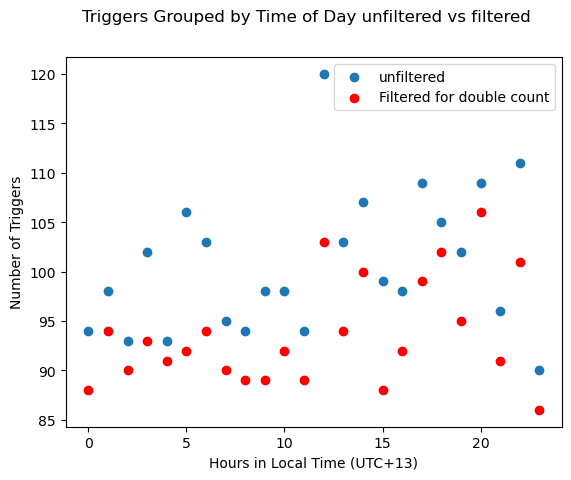

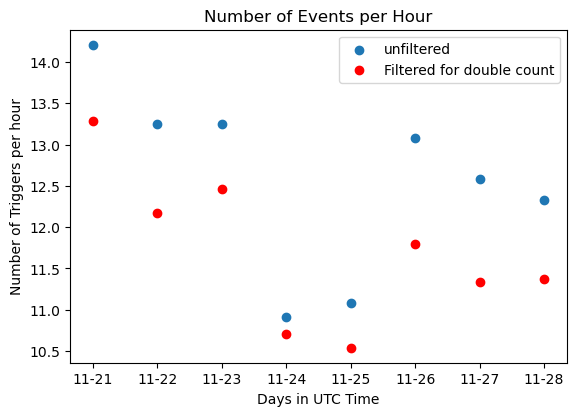

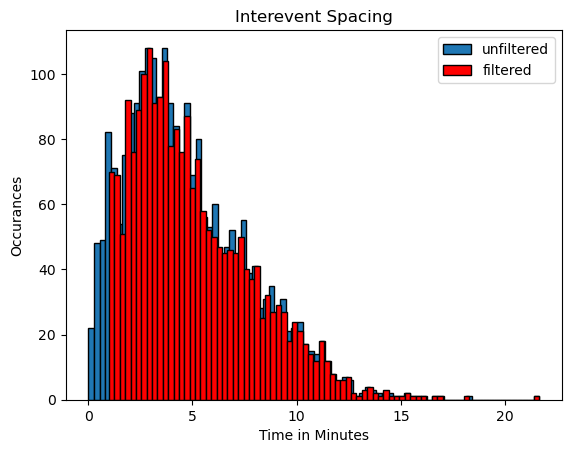

In [8]:
stat_plotter(trigger_df, filtered_df)


In [ ]:
## To DO

#look at data and does it make sense?

#Find 5ish representative signals for future template matching stuff